In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy.stats import friedmanchisquare

In [50]:
outliermeth = 'iqr_outlier'
outliertreatment = 'impute'
normtype = 'robust'

base_dir = Path().resolve()
folderpath = os.path.join(base_dir, "..","Biometrics", "Outputs", f'outlier_{outliertreatment}', outliermeth)
folderpath = os.path.abspath(folderpath)
folderpath


'C:\\Users\\josee\\OneDrive\\Documentos\\GitHub\\neurohumanities-lab\\OfflineProcessing\\Biometrics\\Outputs\\outlier_impute\\iqr_outlier'

In [51]:
scenedata = {}
for scene in range(1,5):
    scenedata.update({scene:pd.read_csv(os.path.join(folderpath,f"biometric_feat_mat_scene_{scene}_{normtype}.csv"))})

In [52]:
scenedata[1]

,Subject,bpm,sdnn,rmssd,pnn50,hr_mad,lf,hf,lf/hf,p_total,lf_nu,hf_nu,mean_eda,mean_tonic,scr_peak_count,scr_sum_amp,scr_mean_amp,scr_mean_risetime,scr_mean_recoverytime
0,1,27.265851,0.501053,0.438220,3.959286,1.000000,0.658718,9.615074,-0.910561,8.093722,-1.175850,1.175850,-1.869668,-2.005230,1.333333,0.312411,-0.391501,0.125606,0.140117
1,1,23.606402,0.336446,0.176520,2.588233,0.333333,-0.943682,-0.410355,-0.936032,-3.068297,-1.226333,1.226333,6.102532,6.404580,-2.666667,6.020218,5.176650,0.592813,2.157798
2,1,26.131619,0.377627,0.028574,4.258618,0.666667,1.365371,5.646010,-0.324439,6.901806,-0.275860,0.275860,4.988539,4.835135,3.333333,28.791726,8.909474,-0.261751,1.541284
3,1,32.370276,0.144462,0.280565,2.901688,0.666667,4.097076,23.145538,-1.396824,22.366259,-2.410005,2.410005,1.956949,2.029053,3.333333,27.915412,7.924146,-0.233643,1.387156
4,1,31.431784,0.306960,0.271519,2.442710,0.333333,1.507184,-3.089449,0.607794,0.877172,1.160150,-1.160150,5.142832,5.286461,-4.666667,19.868149,25.333161,-0.136779,0.385321
5,1,27.366521,0.268592,0.170083,3.710840,0.666667,-0.590906,-1.275231,-0.311428,-2.849637,-0.260270,0.260270,9.994133,10.313768,-2.666667,37.301156,26.690965,0.069058,-0.770642
6,2,1.467319,0.301050,1.842559,2.661378,-1.333333,-0.101512,1.664798,-0.760482,0.093956,-1.370342,1.370342,-2.477826,-2.602707,-1.333333,4.639534,2.359946,1.171668,1.561950
7,2,1.426466,-0.676977,1.017553,1.561191,-1.333333,0.440008,0.067892,0.576057,-0.135201,0.461162,-0.461162,-0.538982,-0.525793,-1.585586,9.705374,6.449814,2.191379,2.040252
8,2,1.965362,-1.336130,0.968721,-0.385736,-1.333333,0.050350,1.291246,-0.625792,0.050692,-0.995591,0.995591,-1.352800,-1.323278,-1.657658,-5.574602,4.876103,-0.011197,1.893082
9,2,2.266557,0.824450,2.015535,0.232165,-0.666667,0.142474,0.754329,-0.407388,-0.063282,-0.542863,0.542863,-0.962685,-0.576492,-1.369369,-1.942099,1.860622,0.340211,1.893082


In [53]:
def remove_outliers_iqr(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return col[(col >= lower) & (col <= upper)]

# scenedataclean = {}
# for scene in range(1,5):
#     data = scenedata[scene].drop(columns=['Subject']).dropna()
#     cleandata = cleandata.apply(remove_outliers_iqr).dropna()
#     scenedataclean.update({scene : cleandata})


In [54]:
# scenedataclean[1]

In [55]:
scenedata[1]

,Subject,bpm,sdnn,rmssd,pnn50,hr_mad,lf,hf,lf/hf,p_total,lf_nu,hf_nu,mean_eda,mean_tonic,scr_peak_count,scr_sum_amp,scr_mean_amp,scr_mean_risetime,scr_mean_recoverytime
0,1,27.265851,0.501053,0.438220,3.959286,1.000000,0.658718,9.615074,-0.910561,8.093722,-1.175850,1.175850,-1.869668,-2.005230,1.333333,0.312411,-0.391501,0.125606,0.140117
1,1,23.606402,0.336446,0.176520,2.588233,0.333333,-0.943682,-0.410355,-0.936032,-3.068297,-1.226333,1.226333,6.102532,6.404580,-2.666667,6.020218,5.176650,0.592813,2.157798
2,1,26.131619,0.377627,0.028574,4.258618,0.666667,1.365371,5.646010,-0.324439,6.901806,-0.275860,0.275860,4.988539,4.835135,3.333333,28.791726,8.909474,-0.261751,1.541284
3,1,32.370276,0.144462,0.280565,2.901688,0.666667,4.097076,23.145538,-1.396824,22.366259,-2.410005,2.410005,1.956949,2.029053,3.333333,27.915412,7.924146,-0.233643,1.387156
4,1,31.431784,0.306960,0.271519,2.442710,0.333333,1.507184,-3.089449,0.607794,0.877172,1.160150,-1.160150,5.142832,5.286461,-4.666667,19.868149,25.333161,-0.136779,0.385321
5,1,27.366521,0.268592,0.170083,3.710840,0.666667,-0.590906,-1.275231,-0.311428,-2.849637,-0.260270,0.260270,9.994133,10.313768,-2.666667,37.301156,26.690965,0.069058,-0.770642
6,2,1.467319,0.301050,1.842559,2.661378,-1.333333,-0.101512,1.664798,-0.760482,0.093956,-1.370342,1.370342,-2.477826,-2.602707,-1.333333,4.639534,2.359946,1.171668,1.561950
7,2,1.426466,-0.676977,1.017553,1.561191,-1.333333,0.440008,0.067892,0.576057,-0.135201,0.461162,-0.461162,-0.538982,-0.525793,-1.585586,9.705374,6.449814,2.191379,2.040252
8,2,1.965362,-1.336130,0.968721,-0.385736,-1.333333,0.050350,1.291246,-0.625792,0.050692,-0.995591,0.995591,-1.352800,-1.323278,-1.657658,-5.574602,4.876103,-0.011197,1.893082
9,2,2.266557,0.824450,2.015535,0.232165,-0.666667,0.142474,0.754329,-0.407388,-0.063282,-0.542863,0.542863,-0.962685,-0.576492,-1.369369,-1.942099,1.860622,0.340211,1.893082


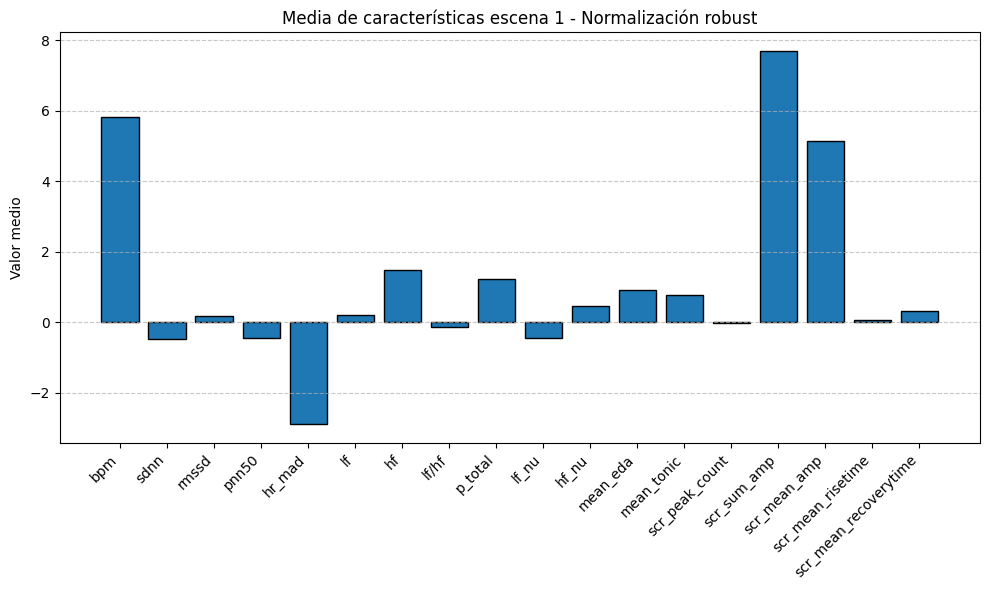

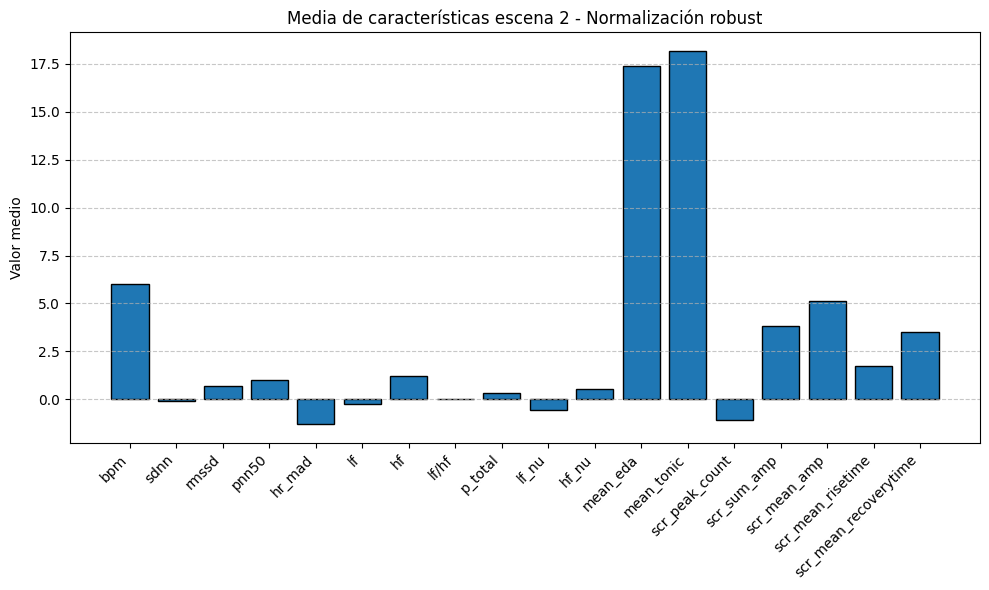

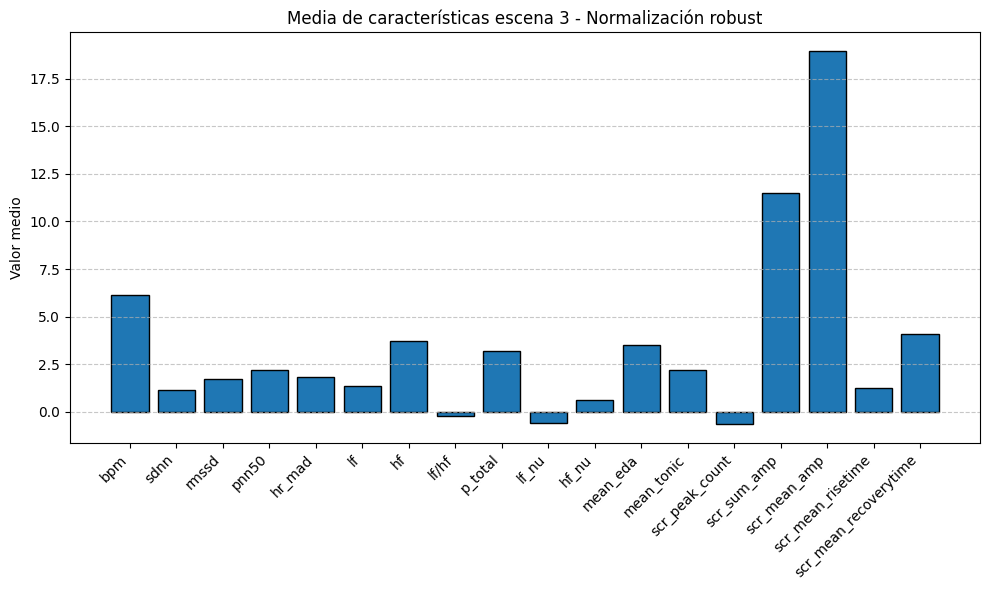

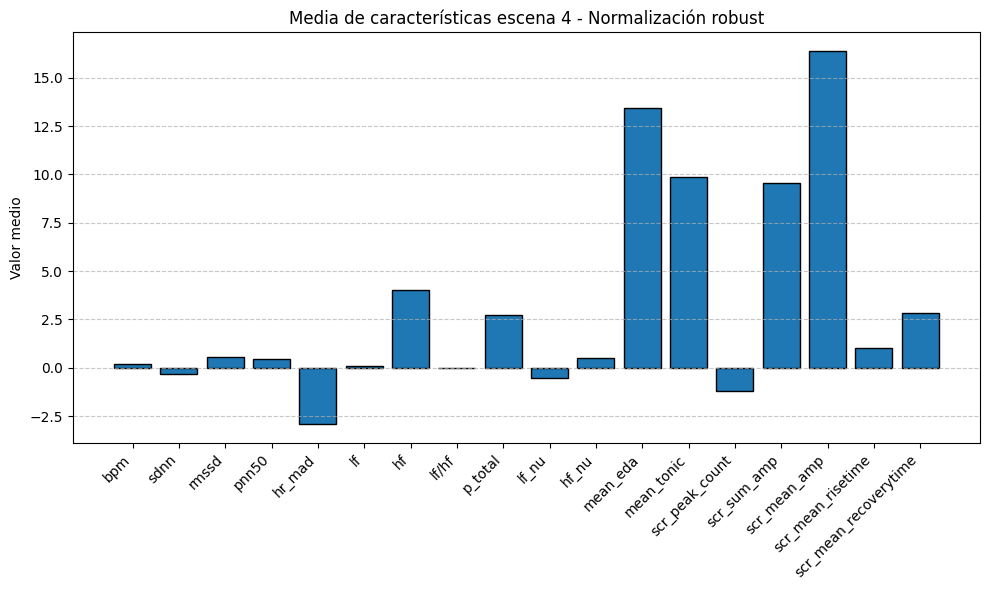

In [56]:
outpath = os.path.join(base_dir, "..","Biometrics", "Outputs", "Figures", f'outlier_{outliertreatment}', outliermeth, normtype)
outpath = os.path.abspath(outpath)


def plot_bars(data, scene=int, normtype=str, savecond=False, savepath=str, showfig=True):
    means = data.mean()
    plt.figure(figsize=(10, 6))
    plt.bar(means.index, means.values, color='#1f77b4', edgecolor='black')
    plt.title(f'Media de características escena {scene} - Normalización {normtype}')
    plt.ylabel('Valor medio')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    if savecond:
        plt.savefig(os.path.join(savepath, f'bar_scene{scene}_{normtype}.png'), dpi=300, bbox_inches='tight')
    if showfig:
        plt.show()
    else:
        plt.close()


for probe in range(1,5):
    plot_bars(scenedata[probe].drop('Subject',axis=1), probe, normtype, savecond=False, savepath=outpath, showfig=True)
    
    

In [57]:
list(scenedata)

[1, 2, 3, 4]

In [58]:
def boxplot_feature_by_context(dfs, labels, feature, title=None, colors=None, showfig=True):
    dfs_list = [dfs[i] for i in sorted(dfs.keys())]

    # Extrae los valores de la característica en cada contexto
    data = [df[feature] for df in dfs_list]

    # Colores por defecto si no se especifican
    if colors is None:
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(dfs)]

    # Gráfico
    plt.figure(figsize=(8, 6))
    box = plt.boxplot(data, patch_artist=True, tick_labels=labels)

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')

    for component in ['whiskers', 'caps', 'medians']:
        for element in box[component]:
            element.set_color('black')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylabel('Valor')
    plt.title(title if title else f'Comparación de "{feature}" entre escenas')
    plt.tight_layout()
    if showfig:
        plt.show()
    else:
        plt.close()

labels = ['Scene 1', 'Scene 2', 'Scene 3', 'Scene 4']
feats = list(scenedata[1].columns)
boxplot_feature_by_context(scenedata, labels, feats[1], showfig=False)

In [59]:
scenedata[1]

,Subject,bpm,sdnn,rmssd,pnn50,hr_mad,lf,hf,lf/hf,p_total,lf_nu,hf_nu,mean_eda,mean_tonic,scr_peak_count,scr_sum_amp,scr_mean_amp,scr_mean_risetime,scr_mean_recoverytime
0,1,27.265851,0.501053,0.438220,3.959286,1.000000,0.658718,9.615074,-0.910561,8.093722,-1.175850,1.175850,-1.869668,-2.005230,1.333333,0.312411,-0.391501,0.125606,0.140117
1,1,23.606402,0.336446,0.176520,2.588233,0.333333,-0.943682,-0.410355,-0.936032,-3.068297,-1.226333,1.226333,6.102532,6.404580,-2.666667,6.020218,5.176650,0.592813,2.157798
2,1,26.131619,0.377627,0.028574,4.258618,0.666667,1.365371,5.646010,-0.324439,6.901806,-0.275860,0.275860,4.988539,4.835135,3.333333,28.791726,8.909474,-0.261751,1.541284
3,1,32.370276,0.144462,0.280565,2.901688,0.666667,4.097076,23.145538,-1.396824,22.366259,-2.410005,2.410005,1.956949,2.029053,3.333333,27.915412,7.924146,-0.233643,1.387156
4,1,31.431784,0.306960,0.271519,2.442710,0.333333,1.507184,-3.089449,0.607794,0.877172,1.160150,-1.160150,5.142832,5.286461,-4.666667,19.868149,25.333161,-0.136779,0.385321
5,1,27.366521,0.268592,0.170083,3.710840,0.666667,-0.590906,-1.275231,-0.311428,-2.849637,-0.260270,0.260270,9.994133,10.313768,-2.666667,37.301156,26.690965,0.069058,-0.770642
6,2,1.467319,0.301050,1.842559,2.661378,-1.333333,-0.101512,1.664798,-0.760482,0.093956,-1.370342,1.370342,-2.477826,-2.602707,-1.333333,4.639534,2.359946,1.171668,1.561950
7,2,1.426466,-0.676977,1.017553,1.561191,-1.333333,0.440008,0.067892,0.576057,-0.135201,0.461162,-0.461162,-0.538982,-0.525793,-1.585586,9.705374,6.449814,2.191379,2.040252
8,2,1.965362,-1.336130,0.968721,-0.385736,-1.333333,0.050350,1.291246,-0.625792,0.050692,-0.995591,0.995591,-1.352800,-1.323278,-1.657658,-5.574602,4.876103,-0.011197,1.893082
9,2,2.266557,0.824450,2.015535,0.232165,-0.666667,0.142474,0.754329,-0.407388,-0.063282,-0.542863,0.542863,-0.962685,-0.576492,-1.369369,-1.942099,1.860622,0.340211,1.893082


In [60]:
feat_cols = [col for col in scenedata[1].columns if col not in ["Subject"]]

org_per_feat = {}
subjects = [1, 2, 3, 4, 6, 8, 9]
for feat in feat_cols:
    aggdata_np = np.zeros([len(subjects),5])
    for i in range(0,len(subjects)):
        scene1 = scenedata[1][scenedata[1]['Subject']==subjects[i]][feat].median()
        scene2 = scenedata[2][scenedata[2]['Subject']==subjects[i]][feat].median()
        scene3 = scenedata[3][scenedata[3]['Subject']==subjects[i]][feat].median()
        scene4 = scenedata[4][scenedata[4]['Subject']==subjects[i]][feat].median()

        aggdata_np[i,:] = np.array([subjects[i], scene1, scene2, scene3, scene4])

    columns = ['Subject', 'scene1', 'scene2', 'scene3', 'scene4']
    aggdata_df = pd.DataFrame(aggdata_np, columns=columns)

    org_per_feat.update({feat:aggdata_df})

org_per_feat['bpm']

,Subject,scene1,scene2,scene3,scene4
0,1.0,27.316186,29.334697,29.370877,6.850681
1,2.0,1.629021,1.524913,3.364879,0.259555
2,3.0,6.970484,0.504630,1.760689,-0.360261
3,4.0,7.902342,1.066593,1.421665,0.696344
4,6.0,-1.418730,1.002058,-1.056882,-1.748357
5,8.0,0.419560,3.732818,1.554283,-1.054166
6,9.0,4.241781,4.816435,3.902630,0.510641


In [61]:
np.zeros([1,4])

array([[0., 0., 0., 0.]])

In [62]:
friedman_list = []
for feat in feat_cols:
    data = org_per_feat[feat].drop('Subject', axis=1)
    stat, p = friedmanchisquare(data['scene1'], data['scene2'], data['scene3'], data['scene4'])
    friedman_list.append([stat, p])

friedman_df = pd.DataFrame(friedman_list, columns=['Statistic', 'p-value'], index=feat_cols)


In [63]:
friedman_df

,Statistic,p-value
bpm,12.771429,0.005158
sdnn,4.200000,0.240662
rmssd,4.200000,0.240662
pnn50,3.857143,0.277309
hr_mad,4.746269,0.191348
lf,4.371429,0.224049
hf,6.600000,0.085801
lf/hf,0.942857,0.815075
p_total,9.685714,0.021436
lf_nu,0.942857,0.815075


In [64]:
friedman_df[friedman_df['p-value']<=0.05]

,Statistic,p-value
bpm,12.771429,0.005158
p_total,9.685714,0.021436
